========== DATASET PREVIEW ==========
   sale_id customer_name product     category  quantity    price       city
0        1         Rahul  Laptop  Electronics         1  55000.0  Bangalore
1        2         Priya   Phone  Electronics         2  25000.0     Mumbai
2        3          Arun   Chair    Furniture         4   3500.0  Bangalore
3        4         Sneha  Laptop  Electronics         1  60000.0      Delhi
4        5         Kiran   Table    Furniture         2   7000.0    Chennai

========== DATASET SHAPE ==========
Rows: 10
Columns: 7

========== DATA TYPES ==========
sale_id            int64
customer_name        str
product              str
category             str
quantity           int64
price            float64
city                 str
dtype: object

========== NULL COUNTS ==========
sale_id          0
customer_name    0
product          0
category         0
quantity         0
price            0
city             0
dtype: int64

========== DUPLICATE ROWS ==========
Duplica

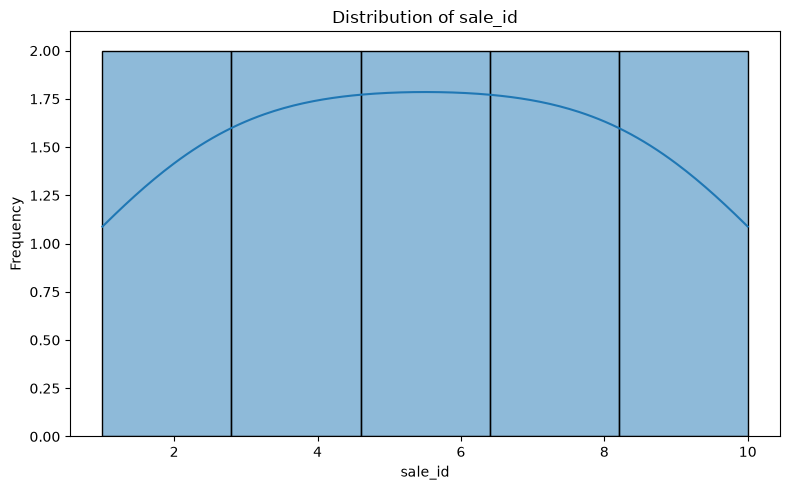

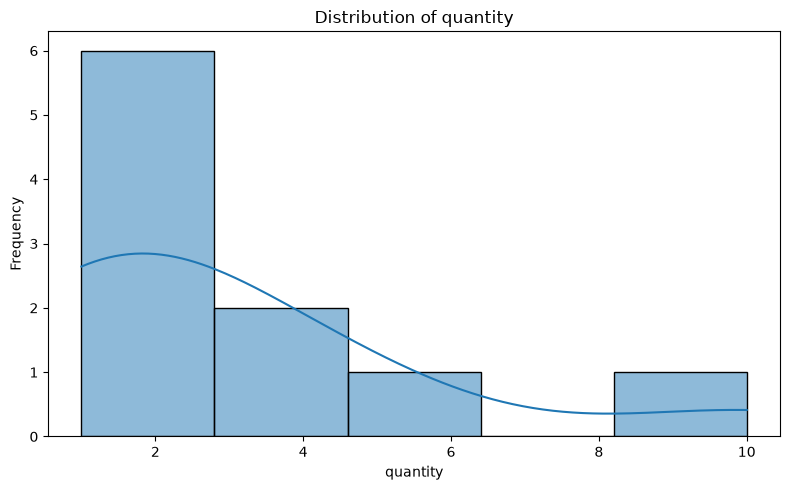

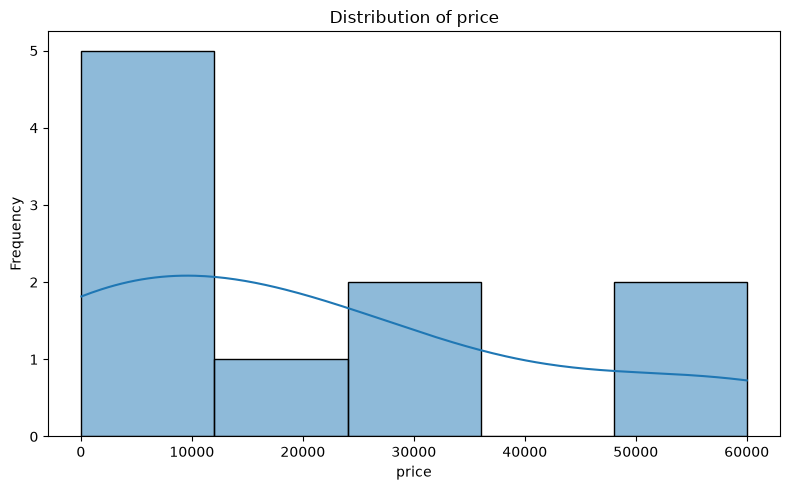


========== CORRELATION MATRIX ==========
           sale_id  quantity     price
sale_id   1.000000  0.272475 -0.489478
quantity  0.272475  1.000000 -0.604006
price    -0.489478 -0.604006  1.000000


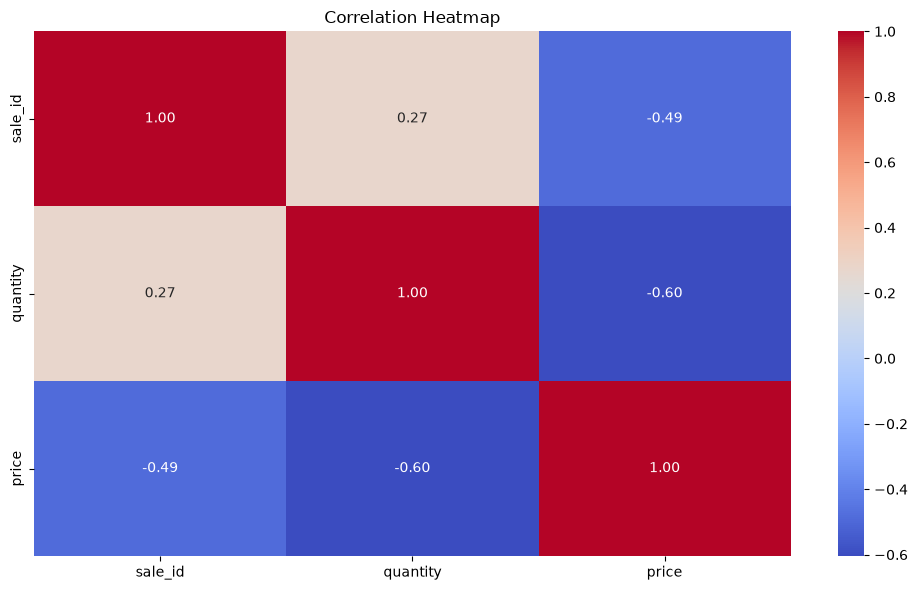


========== BUSINESS INSIGHTS ==========
1. The region with the highest total sales can be identified from the regional sales chart.
2. The best-performing product can be identified from the product sales chart.
3. Monthly sales trends show how sales change over time.
4. The quantity-sales relationship shows whether higher quantities are associated with higher sales.
5. Average sales by region highlights regions with stronger average transaction values.

========== EDA COMPLETED ==========


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("sales result.csv")

print("========== DATASET PREVIEW ==========")
print(df.head())

# ==========================================
# 2. PROFILE DATASET
# ==========================================

print("\n========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== NULL COUNTS ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print("Duplicates:", df.duplicated().sum())

# ==========================================
# 3. SUMMARY STATISTICS
# ==========================================

print("\n========== SUMMARY STATISTICS ==========")
print(df.describe())

summary = df.describe().T
summary["missing"] = df.isnull().sum()
summary["unique"] = df.nunique()

print("\n========== SUMMARY STATISTICS TABLE ==========")
print(summary)

# ==========================================
# 4. NUMERIC COLUMNS
# ==========================================

numeric_cols = df.select_dtypes(include="number").columns

print("\n========== NUMERIC COLUMNS ==========")
print(list(numeric_cols))

# ==========================================
# 5. DISTRIBUTIONS FOR ALL NUMERIC COLUMNS
# ==========================================

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. CORRELATION HEATMAP
# ==========================================

correlation = df[numeric_cols].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================
# 7. BUSINESS INSIGHT 1
# TOTAL SALES BY REGION
# ==========================================

if "region" in df.columns and "sales" in df.columns:
    region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)

    print("\n========== SALES BY REGION ==========")
    print(region_sales)

    region_sales.plot(kind="bar", figsize=(8, 5))
    plt.title("Total Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# 8. BUSINESS INSIGHT 2
# TOTAL SALES BY PRODUCT
# ==========================================

if "product" in df.columns and "sales" in df.columns:
    product_sales = df.groupby("product")["sales"].sum().sort_values(ascending=False)

    print("\n========== SALES BY PRODUCT ==========")
    print(product_sales)

    product_sales.plot(kind="bar", figsize=(8, 5))
    plt.title("Total Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# 9. BUSINESS INSIGHT 3
# MONTHLY SALES TREND
# ==========================================

if "date" in df.columns and "sales" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

    monthly_sales = df.groupby(
        df["date"].dt.to_period("M")
    )["sales"].sum()

    print("\n========== MONTHLY SALES ==========")
    print(monthly_sales)

    monthly_sales.plot(figsize=(10, 5))
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.tight_layout()
    plt.show()

# ==========================================
# 10. BUSINESS INSIGHT 4
# QUANTITY VS SALES
# ==========================================

if "quantity" in df.columns and "sales" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df["quantity"], df["sales"])
    plt.title("Quantity vs Sales")
    plt.xlabel("Quantity")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.show()

    print("\n========== QUANTITY VS SALES CORRELATION ==========")
    print(df["quantity"].corr(df["sales"]))

# ==========================================
# 11. BUSINESS INSIGHT 5
# AVERAGE SALES BY REGION
# ==========================================

if "region" in df.columns and "sales" in df.columns:
    avg_region = df.groupby("region")["sales"].mean().sort_values(ascending=False)

    print("\n========== AVERAGE SALES BY REGION ==========")
    print(avg_region)

    avg_region.plot(kind="bar", figsize=(8, 5))
    plt.title("Average Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Average Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# 12. FINAL BUSINESS INSIGHTS
# ==========================================

print("\n========== BUSINESS INSIGHTS ==========")
print("1. The region with the highest total sales can be identified from the regional sales chart.")
print("2. The best-performing product can be identified from the product sales chart.")
print("3. Monthly sales trends show how sales change over time.")
print("4. The quantity-sales relationship shows whether higher quantities are associated with higher sales.")
print("5. Average sales by region highlights regions with stronger average transaction values.")

print("\n========== EDA COMPLETED ==========")  